# [기초-실습] 통계 101×데이터 분석: (4장) 추론통계~신뢰구간

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [7]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = "Malgun Gothic" # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 문제 1. 표본조사 체험하기

**📘 문제**

- 온라인 쇼핑몰은 전체 고객 수가 너무 많아, 모든 고객을 조사하기 어렵습니다.

- 그래서 무작위로 고객 30명을 뽑아 평균 만족도를 계산하고 이를 전체 만족도의 추정값으로 사용하려 합니다.

- 이번 실습에서는 직접 표본을 뽑고, 표본 평균을 구해보며,
  **“표본마다 결과가 달라질 수 있다”**는 추론 통계의 핵심 개념을 체험해봅니다.

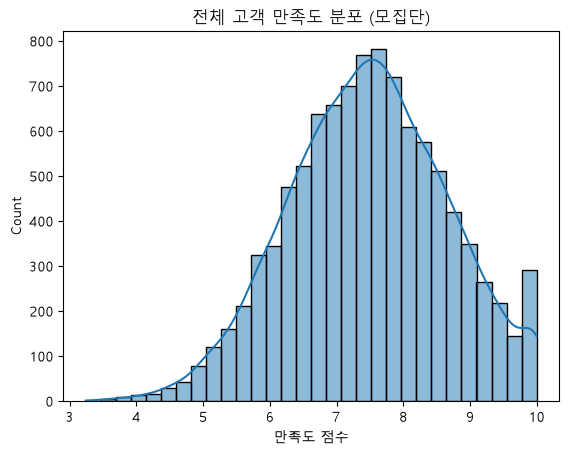

In [8]:
# 모집단 생성 (전체 고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.5, scale=1.2, size=10000)
population = np.clip(population, 1, 10)  # 1점 ~ 10점 사이로 제한
df_pop = pd.DataFrame({'score': population})

# 전체 모집단 시각화
sns.histplot(df_pop['score'], bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 표본을 무작위로 여러 번 뽑아 보고, 표본 평균이 어떻게 변하는지 확인해봅시다.

- 히스토그램을 그리고, 표본 평균의 분포 형태를 관찰해봅시다.

In [9]:
# [문제 1] Q1. 모집단에서 무작위로 30명을 뽑아 표본 평균을 구해봅시다.
# 여기에 코드를 작성해주세요.
sample = np.random.choice(df_pop['score'], size=30, replace=False)
sample_mean = sample.mean()
print("표본 평균:", sample_mean)

표본 평균: 7.201974814386403


In [10]:
# [문제 1] Q2. 이 과정을 500번 반복하고, 표본 평균을 리스트에 저장합니다.
# 여기에 코드를 작성해주세요.
sample_means = []

for i in range(500):
    sample = np.random.choice(df_pop['score'], size=30, replace=False)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)
print("표본 평균 리스트 개수:", len(sample_means))
print("표본 평균들의 평균:", sample_means.mean())

표본 평균 리스트 개수: 500
표본 평균들의 평균: 7.4881149682822645


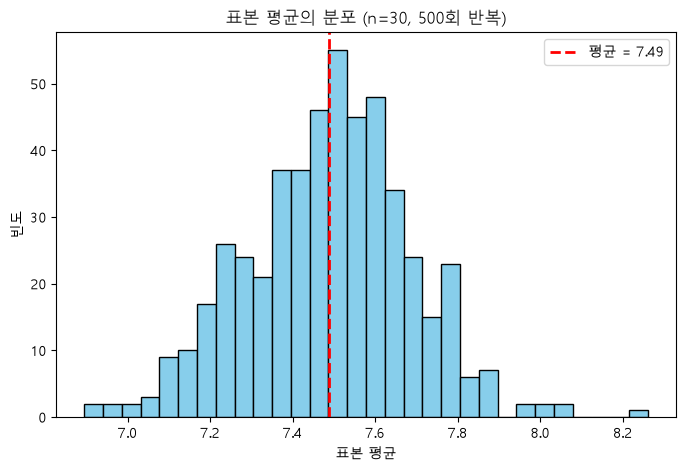

In [11]:
# [문제 1] Q3. 표본 평균들의 분포를 히스토그램으로 그려봅시다. 평균선도 함께 표시해 봅시다.
# 여기에 코드를 작성해주세요.
plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=30, color='skyblue', edgecolor='black')
plt.axvline(sample_means.mean(), color='red', linestyle='--', linewidth=2,
            label=f'평균 = {sample_means.mean():.2f}')

plt.title('표본 평균의 분포 (n=30, 500회 반복)')
plt.xlabel('표본 평균')
plt.ylabel('빈도')
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 표본 평균들은 어떤 값 주변에 많이 분포해 있나요? 이 값은 전체 모집단 평균과 얼마나 비슷한가요?  
: 표본평균의 모집단 평균 근처에 많이 몰려 분포한다. 표본을 많이 반복할수록 표본평균들의 평균은 모집단 평균과 거의 정확히 일치한다. 

- 표본을 1번 뽑았을 때와 500번을 반복해서 뽑았을 때, 표본 평균의 분포나 신뢰성에는 어떤 차이가 있나요  
: 표본을 1번만 뽑으면 표본평균 값 하나만 얻기 때문에 표본평균의 분포를 알 수 없고, 그 값이 모집단 평균에 얼마나 가깝고 신뢰할 수 있는지 판단할 근거가 없다.  
500번 반복해서 뽑으면 표본평균들의 분포를 직접 확인할 수 있고, 표준오차를 계산할 수 있어 추정의 정밀도를 정량적으로 파악할 수 있다. 따라서 반복횟수가 많아질수록 신뢰성이 높아진다.

- 친구가 다른 표본을 뽑았다면 같은 평균이 나왔을까요? 비슷한 결과가 나왔더라도 완전히 같지 않았다면, 그 이유는 무엇일까요?  
: 친구가 다른 표본을 뽑았다면 완전히 같지는 않을 것이다. 데이터 자체에 퍼짐이 있는 모집단에서 무작위 표본을 추출할 때에는 어떤 표본이 뽑히는지에 따라 표본평균 값이 조금씩 달라지는 표본오차가 발생하기 때문이다.

- 표본 평균들의 분포는 어떤 모양인가요? 종 모양의 정규분포처럼 보이나요? 그렇다면 왜 그렇게 되는 걸까요?  
: 종 모양의 정규분포처럼 보인다. 중심극한정리에 의해, 모집단의 원래 분포 형태와 관계없이 표본 크기가 충분히 크면 표본평균들의 분포는 정규분포에 가까워지기 때문이다. 

In [12]:
population.mean()

np.float64(7.480611214490196)

# 문제 2. 중심극한정리

**📘 문제**

- 현실에서는 모집단의 분포가 정규분포가 아닐 수도 있습니다.

- 예를 들어, 일부 고객은 매우 높은 점수를 주고, 대부분은 낮은 점수를 주는 만족도 분포가 있을 수 있죠. (예: 지수분포)

- 이처럼 원래 분포가 비정규분포여도,
  표본을 여러 번 뽑아 평균을 계산하면, 그 평균들의 분포는 정규분포에 가까워진다는 것을
  **중심극한정리(Central Limit Theorem)**라고 합니다.

- 이번 실습에서는 다양한 크기의 표본을 뽑아 평균을 계산하고,
  그 평균들의 분포가 어떻게 변하는지를 직접 실험해 봅니다.

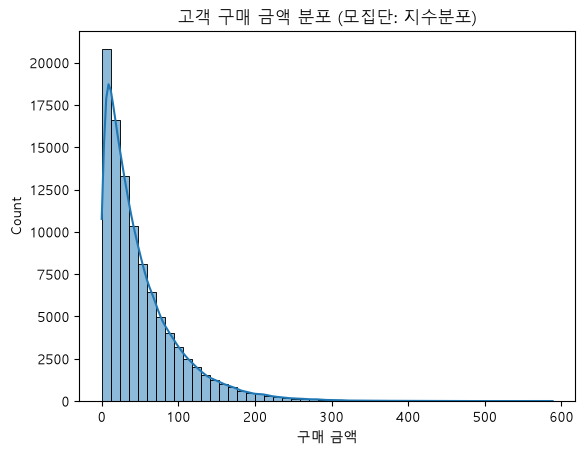

In [13]:
# 지수분포를 따르는 모집단 생성
np.random.seed(2025)
population = np.random.exponential(scale=50, size=100000)  # 평균 50, 비대칭 분포

# 모집단 시각화
sns.histplot(population, bins=50, kde=True)
plt.title("고객 구매 금액 분포 (모집단: 지수분포)")
plt.xlabel("구매 금액")
plt.show()

**📌 아래를 수행해 보세요:**

- 비대칭적인 모집단(지수분포)에서 무작위로 표본을 추출해 평균을 구해봅시다.

- 표본 크기를 바꿔가며, 표본 평균들의 분포가 어떻게 변화하는지 확인해봅시다.

- 히스토그램을 그리고, 분포의 모양을 관찰해봅시다.

- 표본 크기가 커질수록 표본 평균 분포의 모양과 **퍼진 정도(분산)**가 어떻게 변하는지 관찰해봅시다.

In [14]:
# [문제 2] Q1. 모집단에서 표본을 1000번 뽑고, 각 표본의 평균을 구해봅시다.
# 표본 크기 = 5일 때

# 여기에 코드를 작성해주세요.
sample_size = 5
n_repeat = 1000

sample_means_5 = []
for i in range(n_repeat):
    sample = np.random.choice(population, size=sample_size, replace=False)
    sample_means_5.append(sample.mean())

sample_means_5 = np.array(sample_means_5)
print("표본크기 5 - 표본평균들의 평균:", sample_means_5.mean())

표본크기 5 - 표본평균들의 평균: 49.410453021134806


In [15]:
# [문제 2] Q2. 위 과정을 표본 크기 30, 100일 때도 반복해봅시다.
# sample_size = 30, 100

# 여기에 코드를 작성해주세요.
def get_sample_means(population, sample_size, n_repeat=1000):
    means = []
    for i in range(n_repeat):
        sample = np.random.choice(population, size=sample_size, replace=False)
        means.append(sample.mean())
    return np.array(means)

sample_means_30 = get_sample_means(population, sample_size=30, n_repeat=1000)
sample_means_100 = get_sample_means(population, sample_size=100, n_repeat=1000)

print("표본크기 30 - 표본평균들의 평균:", sample_means_30.mean())
print("표본크기 100 - 표본평균들의 평균:", sample_means_100.mean())

표본크기 30 - 표본평균들의 평균: 50.55640273124097
표본크기 100 - 표본평균들의 평균: 50.21193153035717


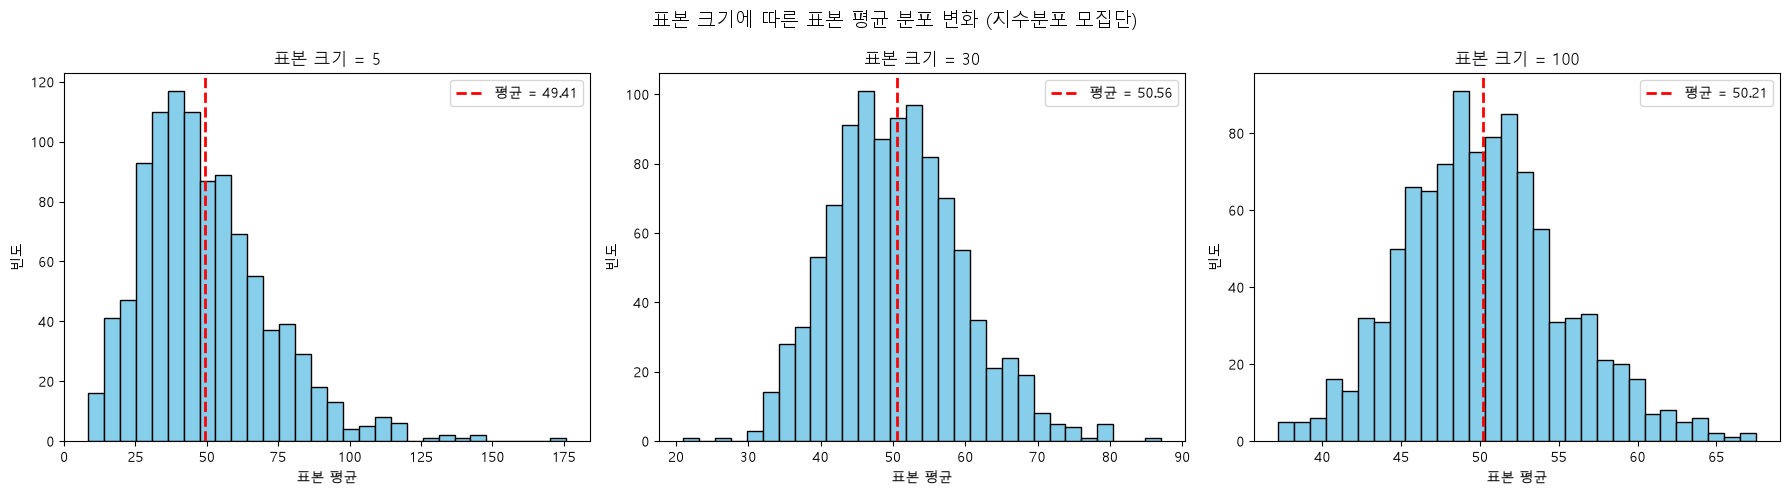

In [16]:
# [문제 2] Q3. 각 표본 크기별로 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 평균선을 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.
sample_dict = {
    5: sample_means_5,
    30: sample_means_30,
    100: sample_means_100
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (size, means) in zip(axes, sample_dict.items()):
    ax.hist(means, bins=30, color='skyblue', edgecolor='black')
    ax.axvline(means.mean(), color='red', linestyle='--', linewidth=2,
               label=f'평균 = {means.mean():.2f}')
    ax.set_title(f'표본 크기 = {size}')
    ax.set_xlabel('표본 평균')
    ax.set_ylabel('빈도')
    ax.legend()

plt.suptitle('표본 크기에 따른 표본 평균 분포 변화 (지수분포 모집단)', fontsize=14)
plt.tight_layout()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 표본 크기가 작을 때 (예: 5), 평균들의 분포는 어떤 모양인가요?  
: 표본 크기가 작을 때에는 표본평균의 분포가 모집단의 분포와 비슷한 비대칭 분포를 가진다.

- 표본 크기가 커질수록 평균 분포의 모양은 어떤 변화를 보이나요?  
: 표본의 크기가 커질수록 정규분포 형태를 띤다.

- 원래 모집단은 비대칭이었는데, 왜 평균들의 분포는 정규분포처럼 바뀌었을까요?  
: 표본평균은 여러개의 값을 뽑아서 평균을 낸 값이다.이 과정에서 뽑힌 큰 값들과 작은 값들이 서로 상쇄되기 때문에 모집단의 분포와 상관없이 표본평균은 모평균 주변으로 모이면서 정규분포 모양이 된다.


- 이 실험을 통해 중심극한정리를 어떻게 이해하게 되었나요?  
: 모집단의 분포와 상관없이 표본크기 n이 커지면 표본평균의 분포가 정규분포를 따르게 된다.

- 표본 크기에 따라 **분포의 넓이(흩어짐)**는 어떻게 달라지나요?  
: 표본평균의 표준편차(표본오차)는 σ/√n 이므로, 표본크기 n이 커질수록 분모가 커져 표준오차는 작아진다.

# 문제 3. 표준오차

**📘 문제**

- 앞선 실습에서 우리는 **표본 크기(n)가 커질수록 표본 평균들의 분포가 더 좁아진다**는 것을 확인했습니다.
- 이처럼 표본 평균들이 얼마나 흩어져 있는지(분포의 퍼진 정도)를 나타내는 값을 **표준오차(Standard Error, SE)**라고 부릅니다.
- 표준오차는 **표본 평균들의 표준편차**와 같은 의미이며, 이는 우리가 뽑은 표본 평균이 실제 모평균과 평균적으로 얼마나 떨어져 있을지를 나타내는 **'예상 오차의 크기'**입니다.

- 통계학적으로 이 표준오차는 **`SE = σ / √n`** (모집단 표준편차 / 표본 크기의 제곱근) 이라는 공식으로 계산할 수 있습니다.
- 이 공식은 **표본 크기(n)가 커질수록 표준오차(SE)가 작아진다**는 것을 명확히 보여줍니다.

- 이번 실습에서는 여러 크기의 표본을 뽑아, 시뮬레이션을 통해 얻은 **표본 평균들의 표준편차(실험값)**가 공식으로 계산한 **표준오차(이론값)**와 얼마나 일치하는지 직접 확인해봅니다.

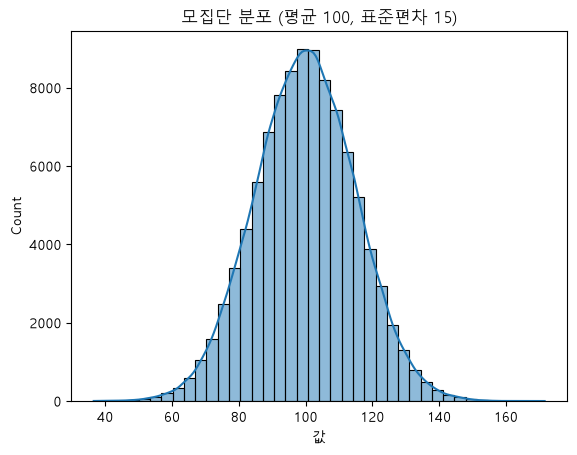

In [17]:
# 모집단 생성 (평균 100, 표준편차 15)
np.random.seed(2025)
population = np.random.normal(loc=100, scale=15, size=100000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 100, 표준편차 15)")
plt.xlabel("값")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단에서 여러 크기의 표본(10, 30, 100, 500)을 각각 1000번 뽑고, 그 평균들을 구한 뒤, **표본 평균들의 표준편차(=실험적 표준오차)**를 계산해봅시다.

- 이 결과를 이론적인 표준오차 공식과 비교하는 표를 만들고, 시각화해봅시다.

In [18]:
# [문제 3] Q1. 표본 크기 10, 30, 100, 500에 대해 각각 1000번 표본을 뽑고, 평균을 구해봅시다.
# 각 표본 평균 분포의 표준편차를 계산해봅시다.
# 결과를 리스트에 저장하고, 표로 정리해봅시다.

# 여기에 코드를 작성해주세요.
import numpy as np

sample_sizes = [10, 30, 100, 500]
n_repeat = 1000

results = []  # 표로 정리할 리스트

for size in sample_sizes:
    means = []
    for i in range(n_repeat):
        sample = np.random.choice(population, size=size, replace=False)
        means.append(sample.mean())
    means = np.array(means)
    
    empirical_se = means.std()  # 실험적으로 구한 표준오차
    results.append({
        'sample_size': size,
        'sample_means': means,          
        'empirical_se': empirical_se
    })

# 표로 정리
df_result = pd.DataFrame([{'표본크기': r['sample_size'], 
                             '실험적 표준오차': r['empirical_se']} 
                            for r in results])
print(df_result)

   표본크기  실험적 표준오차
0    10  4.656751
1    30  2.784682
2   100  1.525275
3   500  0.663055


In [19]:
# [문제 3] Q2. 이론적인 표준오차와 비교해봅시다.
# [공식] 표준오차(SE) = 모집단 표준편차 / √표본크기

# 여기에 코드를 작성해주세요.
pop_std = population.std()  # 모집단 표준편차
df_result['이론적 표준오차'] = pop_std / np.sqrt(df_result['표본크기'])

print(df_result)

   표본크기  실험적 표준오차  이론적 표준오차
0    10  4.656751  4.753921
1    30  2.784682  2.744677
2   100  1.525275  1.503322
3   500  0.663055  0.672306


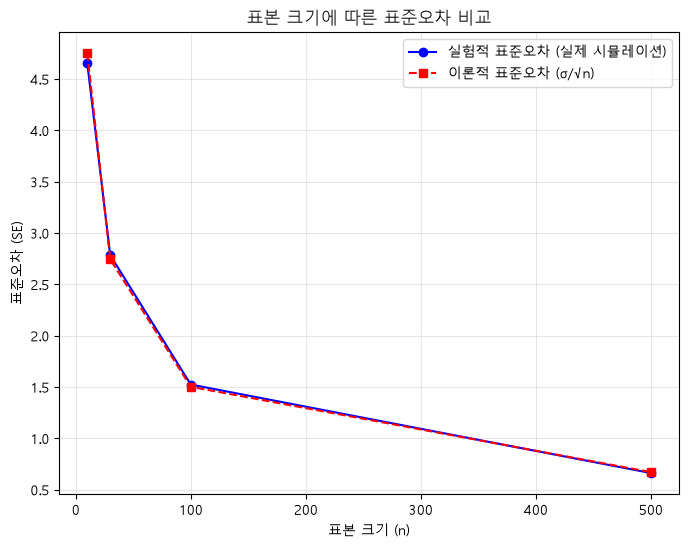

In [20]:
# [문제 3] Q3. 실험값과 이론값을 시각화해봅시다.
# 표본 크기를 x축, 표준오차를 y축으로 한 꺾은선 그래프를 그려봅시다.

# 여기에 코드를 작성해주세요.
plt.figure(figsize=(8, 6))

plt.plot(df_result['표본크기'], df_result['실험적 표준오차'], 
         marker='o', linestyle='-', color='blue', label='실험적 표준오차 (실제 시뮬레이션)')
plt.plot(df_result['표본크기'], df_result['이론적 표준오차'], 
         marker='s', linestyle='--', color='red', label='이론적 표준오차 (σ/√n)')

plt.title('표본 크기에 따른 표준오차 비교')
plt.xlabel('표본 크기 (n)')
plt.ylabel('표준오차 (SE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 표본 크기가 작을수록, 표본 평균의 분포는 어떤 모양인가요? 넓게 퍼져 있나요?  
: 표본의 크기가 작을수록 표준오차가 크다. 즉, 표본 평균의 분포가 넓게 퍼져있다.

- 표본 크기가 커질수록, 평균 분포는 어떻게 변하나요?  
: 표본크기가 커질수록 표본평균이 모평균 주변에 몰리면서 분포의 폭이 좁아진다.

- 실험값과 이론값(공식 계산값)은 얼마나 비슷한가요?  
: 실험값과 이론값이 거의 일치한다.

- 왜 표본 크기가 커질수록 표준오차는 작아질까요?  
: 표본의 크기가 커지면 표준오차 공식(σ/√n)에서 분모가 커지기 때문에 표준오차는 작아진다.  
표본의 크기가 클수록 극단적인 값들이 서로 상쇄될 기회가 많아지기 때문에 뽑을 때마다 표본 평균이 크게 요동치지 않고, 모평균 근처에 안정적으로 모이게 된다.

# 문제 4. 신뢰구간 계산과 해석

**📘 문제**

- 표본 평균은 모집단 평균을 추정하는 좋은 점 추정(Point Estimation) 값이지만, 표본오차 때문에 정확히 일치하지는 않습니다.

- 그래서 우리는 "모집단 평균이 아마 이 범위 안에 있을 것이다"라고 **구간으로 추정(Interval Estimation)**하는 것이 더 합리적입니다. 이때 사용하는 개념이 바로 **신뢰구간(Confidence Interval)**입니다.

- 신뢰구간은 표본평균 ± 오차범위 형태로 계산되며, 이 오차범위는 신뢰수준(예: 95%, 99%)과 표본오차에 의해 결정됩니다.

- 이번 실습에서는 **모집단 표준편차(σ)를 알 때(z-분포)**와 **모를 때(t-분포)**의 신뢰구간을 각각 계산해보고, 신뢰수준에 따라 구간의 폭이 어떻게 변하는지 확인해봅니다.

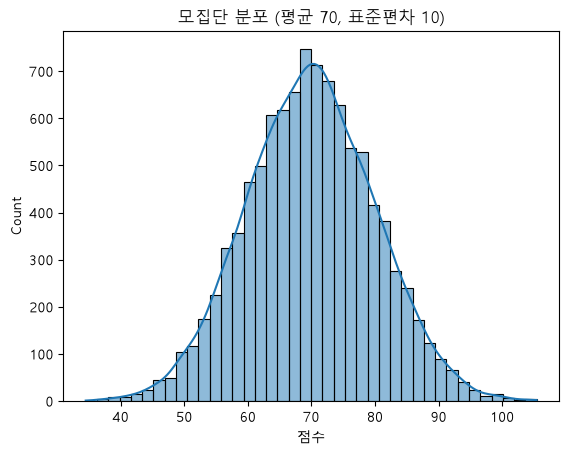

In [21]:
# 모집단 생성
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 70, 표준편차 10)")
plt.xlabel("점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단에서 30명을 무작위로 뽑아 평균, 표준편차, 표준오차를 계산해보세요.

- 95% 신뢰구간을 z-분포와 t-분포를 각각 사용해서 계산해보세요.

- 신뢰수준을 바꿨을 때(90%, 99%) 신뢰구간이 어떻게 변하는지 확인해보세요.

In [22]:
# [문제 4] Q1. 모집단에서 표본 30명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
# 표준오차도 함께 계산해보세요.

# 여기에 코드를 작성해주세요.
np.random.seed(2025)  # 재현성을 위해 표본 추출 시점에도 시드 고정
sample = np.random.choice(population, size=30, replace=False)

sample_mean = sample.mean()
sample_std = sample.std(ddof=1)  # 표본표준편차 (n-1로 나눔)
n = len(sample)
se = sample_std / np.sqrt(n)  # 표준오차 (표본표준편차 기반)

print("표본 평균:", sample_mean)
print("표본 표준편차:", sample_std)
print("표준오차(SE):", se)

표본 평균: 69.20618524443573
표본 표준편차: 7.875499169121773
표준오차(SE): 1.4378628488470628


In [23]:
# [문제 4] Q2. 모집단의 표준편차를 알고 있다고 가정하고, z-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

# 여기에 코드를 작성해주세요.
from scipy import stats
pop_std = population.std()

confidence = 0.95
z_critical = stats.norm.ppf(1 - (1 - confidence) / 2)  # 약 1.96

se_z = pop_std / np.sqrt(n)  # 모집단 표준편차 기반 표준오차
margin_of_error_z = z_critical * se_z

ci_z_lower = sample_mean - margin_of_error_z
ci_z_upper = sample_mean + margin_of_error_z

print(f"\n[Z 신뢰구간 95%] z값: {z_critical:.4f}")
print(f"신뢰구간: ({ci_z_lower:.3f}, {ci_z_upper:.3f})")
print(f"구간 폭: {ci_z_upper - ci_z_lower:.3f}")


[Z 신뢰구간 95%] z값: 1.9600
신뢰구간: (65.626, 72.786)
구간 폭: 7.160


In [24]:
# [문제 4] Q3. 모집단의 표준편차를 모른다고 가정하고, 표본 표준편차와 t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

# 여기에 코드를 작성해주세요.
df = n - 1  # 자유도
t_critical = stats.t.ppf(1 - (1 - confidence) / 2, df)

margin_of_error_t = t_critical * se  # 표본표준편차 기반 SE 사용

ci_t_lower = sample_mean - margin_of_error_t
ci_t_upper = sample_mean + margin_of_error_t

print(f"\n[T 신뢰구간 95%] t값: {t_critical:.4f} (자유도={df})")
print(f"신뢰구간: ({ci_t_lower:.3f}, {ci_t_upper:.3f})")
print(f"구간 폭: {ci_t_upper - ci_t_lower:.3f}")


[T 신뢰구간 95%] t값: 2.0452 (자유도=29)
신뢰구간: (66.265, 72.147)
구간 폭: 5.882


In [25]:
# [문제 4] Q4. 신뢰수준을 90%, 99%로 바꿔가며 신뢰구간을 계산해보고, 그 폭을 비교해봅시다.

# 여기에 코드를 작성해주세요.
confidence_levels = [0.90, 0.95, 0.99]
results = []

for conf in confidence_levels:
    t_crit = stats.t.ppf(1 - (1 - conf) / 2, df)
    margin = t_crit * se
    lower = sample_mean - margin
    upper = sample_mean + margin
    width = upper - lower
    
    results.append({
        '신뢰수준': f"{int(conf*100)}%",
        't값': round(t_crit, 4),
        '신뢰구간 하한': round(lower, 3),
        '신뢰구간 상한': round(upper, 3),
        '구간 폭': round(width, 3)
    })

df_ci = pd.DataFrame(results)
print("\n[신뢰수준별 신뢰구간 비교]")
print(df_ci)


[신뢰수준별 신뢰구간 비교]
  신뢰수준      t값  신뢰구간 하한  신뢰구간 상한   구간 폭
0  90%  1.6991   66.763   71.649  4.886
1  95%  2.0452   66.265   72.147  5.882
2  99%  2.7564   65.243   73.169  7.927


**🧠 데이터를 어떻게 읽을까요?**

- z-분포와 t-분포를 사용한 신뢰구간은 얼마나 차이가 있나요?  
: z-분포의 신뢰구간(7.160)이 t-분포의 신뢰구간(5.882) 보다 더 넓다.  
이는 t-임계값(2.045)이 z-임계값(1.96)보다 원래 더 크지만, z-분포에 사용한 모집단 표준편차(σ)가 t-분포에 사용한 표본 표준편차(s) 보다 더 컸기 때문이다.

- 신뢰수준이 높아질수록 신뢰구간의 폭은 어떻게 변하나요? 왜 그럴까요?  
: 신뢰수준이 높아질수록 신뢰구간의 폭이 커진다. 신뢰수준이 높아질수록 임계값이 커져 ± 오차범위가 커지기 때문이다.

- 신뢰구간이 넓다는 건 좋은 걸까요? 나쁜 걸까요?  
: 신뢰구간이 넓다는 것은 추정의 정밀도가 낮고, 표본 크기가 작거나 신뢰수준이 높다는 것을 의미한다. 신뢰구간이 넓을수록 추정의 정밀도가 낮다는 뜻으로 일반적으로 좋지 않다(모평균이 어디쯤 있는지 콕 집어 말하기 어렵다는 의미이기 때문). 이상적인 것은 신뢰수준은 유지하면서 표본크기를 늘려 구간을 좁히는 것이다.


- 이 데이터가 실제 고객 만족도라면, 신뢰구간 정보를 마케팅 전략에 어떻게 활용할 수 있을까요?  
: 신뢰구간의 하한선이 목표 점수보다 높으면, 목표를 달성했다고 할 수 있다. 신뢰구간의 폭이 너무 넓으면 표본의 크기가 적었다는 신호일 수 있기 때문에 설문을 더 모아야 될 수 있다.

# 문제 5. 미니 프로젝트 - 고객 만족도 신뢰구간 추정

**📘 문제**

- 전체 고객 10,000명을 대상으로 만족도 조사를 하는 것은 시간과 비용이 많이 듭니다.
- 그래서 우리는 무작위로 일부 고객만 조사하여, 전체 고객의 평균 만족도를 추정하려 합니다.

- 이 프로젝트에서는 실제와 같은 상황을 가정하여, 표본을 뽑고 신뢰구간을 계산한 뒤, 이 결과를 바탕으로 마케팅 전략에 어떻게 활용할 수 있을지까지 생각해보는 실습을 진행합니다.

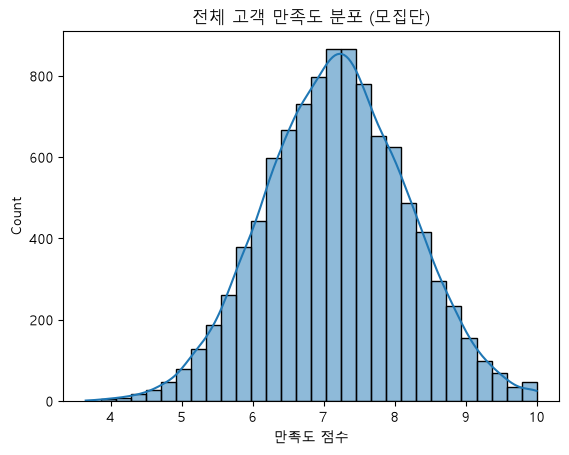

In [26]:
# 모집단 생성 (고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.2, scale=1.0, size=10000)
population = np.clip(population, 1, 10)

# 모집단 시각화
sns.histplot(population, bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단을 생성하고, 거기서 표본을 40명 뽑아 평균을 계산해봅시다.

- 표본 평균과 표준편차를 바탕으로 95% 신뢰구간을 계산해봅시다.

- 히스토그램을 그리고 신뢰구간을 시각화해봅시다.

- 이 결과를 어떻게 해석하고, 마케팅 전략에 활용할 수 있을지 생각해봅시다.

In [27]:
# [문제 5] Q1. 모집단에서 표본 40명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
# 여기에 코드를 작성해주세요.

np.random.seed(2025)
sample = np.random.choice(population, size=40, replace=False)

sample_mean = sample.mean()
sample_std = sample.std(ddof=1)  # 표본표준편차 (n-1)
n = len(sample)

print("표본 평균:", sample_mean)
print("표본 표준편차:", sample_std)

표본 평균: 7.225809160271515
표본 표준편차: 0.8972963814022722


In [28]:
# [문제 5] Q2. 표준오차(SE)를 구하고, t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.
# 여기에 코드를 작성해주세요.
se = sample_std / np.sqrt(n)

confidence = 0.95
df = n - 1
t_critical = stats.t.ppf(1 - (1 - confidence) / 2, df)

margin_of_error = t_critical * se
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print("\n표준오차(SE):", se)
print(f"t값 (자유도={df}):", t_critical)
print(f"95% 신뢰구간: ({ci_lower:.3f}, {ci_upper:.3f})")


표준오차(SE): 0.14187501507291653
t값 (자유도=39): 2.022690920036761
95% 신뢰구간: (6.939, 7.513)


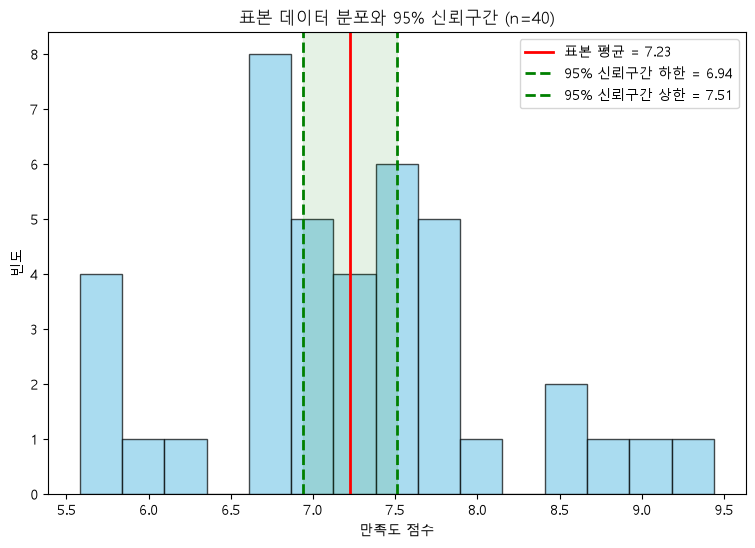

In [29]:
# [문제 5] Q3. 표본 데이터의 히스토그램을 그리고, 평균 및 신뢰구간을 함께 시각화해봅시다.
#  여기에 코드를 작성해주세요.
plt.figure(figsize=(9, 6))

plt.hist(sample, bins=15, color='skyblue', edgecolor='black', alpha=0.7)

# 평균선
plt.axvline(sample_mean, color='red', linestyle='-', linewidth=2,
            label=f'표본 평균 = {sample_mean:.2f}')

# 신뢰구간 (하한/상한)
plt.axvline(ci_lower, color='green', linestyle='--', linewidth=2,
            label=f'95% 신뢰구간 하한 = {ci_lower:.2f}')
plt.axvline(ci_upper, color='green', linestyle='--', linewidth=2,
            label=f'95% 신뢰구간 상한 = {ci_upper:.2f}')

# 신뢰구간 영역 음영 표시
plt.axvspan(ci_lower, ci_upper, color='green', alpha=0.1)

plt.title('표본 데이터 분포와 95% 신뢰구간 (n=40)')
plt.xlabel('만족도 점수')
plt.ylabel('빈도')
plt.legend()
plt.show()

In [30]:
# [문제 5] Q4. 신뢰구간의 결과에 따라 어떤 구체적인 마케팅 전략을 세울 수 있을까요?
# 여기에 의견을 작성해주세요.

# 신뢰구간이 6.94~7.51이므로, "고객 만족도 7점 이상"과 같은 마케팅 문구 활용

# 신뢰구간별
# 신뢰구간이 좁다면, 현재 서비스 만족도가 안정적으로 유지된다는 뜻이므로, 이를 근거로 "검증된 고객 만족도"를 브랜드 신뢰도 강화에 활용
# 신뢰구간이 넓다면, 표본크기 작거나 편차가 크다는 뜻이므로, 표본 크기를 늘리고, 설문 대상을 더 세분화하여 설문 진행.

**🧠 데이터를 어떻게 읽을까요?**

- 신뢰구간은 몇 점에서 몇 점 사이인가요?  
: 약 6.9점에서 7.5점 사이

- 이 구간은 전체 모집단 평균을 포함하고 있나요?  
: 전체 모집단의 평균(7.2)을 포함한다.

- 이 결과를 바탕으로 고객 만족도가 충분히 높다고 말할 수 있을까요?  
: 목표 점수가 신뢰구간의 하한 보다 낮았다면, 대부분의 점수가 목표 점수를 넘었으므로 고객 만족도가 충분히 높다고 말할 수 있다.

- 만약 신뢰구간이 너무 넓게 나왔다면, 그 이유는 무엇이고 어떻게 개선할 수 있을까요?  
: 신뢰구간이 너무 넓다면 표본의 크기가 너무 작거나 표본의 표준편차가 크다는 의미이다.  
더 많은 설문조사를 통해 표본의 크기를 증가시키거나 조사 대상을 더 세분화해 응답 편차 자체를 줄인다.